In [11]:
#7.1
import numpy as np
from numpy import linalg as la

a1 = np.array([1,2,3])
a2 = np.array([0,-4,1])
a3 = np.array([0,3,-1])
aaa = np.stack((a1, a2, a3), axis = 0)
print(la.det(aaa))
b = np.array([2,2,-1])
minv = la.inv(aaa)
print(minv@b)
print(np.array_equal(aaa.T, la.inv(aaa)))
labda, v = la.eig(aaa)
print(labda)

1.0
[10. -1. -2.]
False
[ 1.         -4.79128785 -0.20871215]


In [25]:
#7.3
import numpy as np
from numpy import linalg as la
a1 = (180-123)*2*np.pi/360
a2 = (90-27.4)*2*np.pi/360
a3 = (192.25)*2*np.pi/360
def ex(tita):
    return np.stack((np.array([np.cos(tita),np.sin(tita),0]),np.array([-1*np.sin(tita),np.cos(tita),0]) ,np.array([0,0,1])),axis=0)
def ey(tita):
    return np.stack((np.array([np.cos(tita),0,-1*np.sin(tita)]),np.array([0,1,0]) ,np.array([np.sin(tita),0,np.cos(tita)])),axis=0)
def ez(tita):
    return np.stack((np.array([np.cos(tita),np.sin(tita),0]),np.array([-1*np.sin(tita),np.cos(tita),0]) ,np.array([0,0,1])),axis=0)
    
ee = ex(a1)@ey(a2)@ez(a3)
print(ee)

test = np.array([6,7,8])
print(la.norm(test))
print(la.norm(ee@test))

labda, v = la.eig(ee)
print(labda)

p1 = (27.4)*2*np.pi/360
p2 = (192.25)*2*np.pi/360

pole = np.array([np.cos(p1)*np.cos(p2), np.cos(p1)*np.sin(p2), np.sin(p1)])

print(pole)
print(la.norm(pole))

epole = ee@pole
print(epole)
print(la.norm(epole))

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
12.206555615733702
12.206555615733702
[-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
[-0.86760081 -0.1883746   0.46019978]
1.0
[ 5.55111512e-17 -5.55111512e-17  1.00000000e+00]
1.0


[[5.15978035e+00 4.29981696e+00 3.58318080e+00 2.98598400e+00
  2.48832000e+00 2.07360000e+00 1.72800000e+00 1.44000000e+00
  1.20000000e+00 1.00000000e+00]
 [5.12000000e+02 2.56000000e+02 1.28000000e+02 6.40000000e+01
  3.20000000e+01 1.60000000e+01 8.00000000e+00 4.00000000e+00
  2.00000000e+00 1.00000000e+00]
 [2.64396222e+04 8.52891037e+03 2.75126141e+03 8.87503681e+02
  2.86291510e+02 9.23521000e+01 2.97910000e+01 9.61000000e+00
  3.10000000e+00 1.00000000e+00]
 [6.18121840e+05 1.40482236e+05 3.19277810e+04 7.25631386e+03
  1.64916224e+03 3.74809600e+02 8.51840000e+01 1.93600000e+01
  4.40000000e+00 1.00000000e+00]
 [1.62841360e+06 3.32329306e+05 6.78223073e+04 1.38412872e+04
  2.82475249e+03 5.76480100e+02 1.17649000e+02 2.40100000e+01
  4.90000000e+00 1.00000000e+00]
 [7.42765874e+06 1.28063082e+06 2.20798417e+05 3.80686925e+04
  6.56356768e+03 1.13164960e+03 1.95112000e+02 3.36400000e+01
  5.80000000e+00 1.00000000e+00]
 [3.54520878e+07 5.13798374e+06 7.44635325e+05 1.07918163e

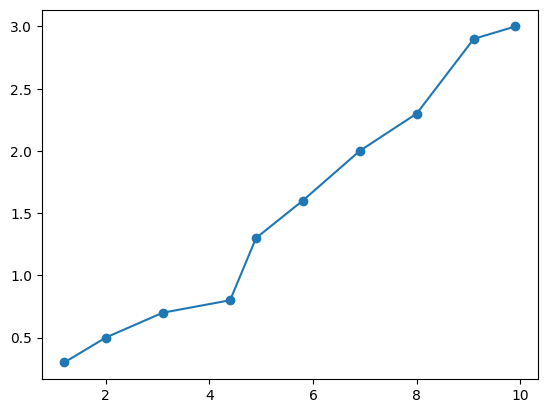

In [23]:
#7.5
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])


n = len(x)
A = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        A[i, j] = x[i] ** (n - 1 - j)
    
A = np.array(A)
poly = np.reshape(A, (len(x),len(x)))
print(A)
ans = la.solve(A, y)
print(ans)

def formula(arr):
    return ans[0]*(arr**9) + ans[1]*(arr**8) +  ans[2]*(arr**7) + ans[3]*(arr**6) + ans[4]*(arr**5) + ans[5]*(arr**4) + ans[6]*(arr**3) + ans[7]*arr**2 + ans[8]*arr + ans[9]

plt.scatter(x, y)
plt.plot(x, formula(x))

[0.32630735 0.45179824 0.66845094 1.0197596  1.18442353 1.51733994
 1.96799751 2.42376169 2.81928086 3.02088035]
1.9272727272727272
1.8840923354401689
1.9290775555378994


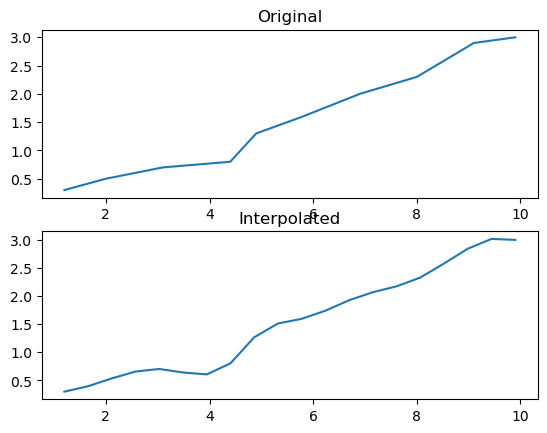

In [27]:
#7.6
from scipy import interpolate as ip
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2)

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
f = ip.interp1d(x, y, kind='cubic')

bigx = np.linspace(1.2, 9.9, 20)
pll = f(bigx)

ax[0].plot(x,y)
ax[0].set_title('Original')
ax[1].plot(bigx,pll)
ax[1].set_title('Interpolated')

class interpolation:
    def __init__(self,x,y):
        self.x = x
        self.y = y
        
    def poll(self, rang=x, typ='polynomial', degree=4, **kwargs):
        if typ == 'linear':
            return np.interp(rang, self.x, self.y)
        elif typ == 'polynomial':
            z = np.polyfit(x, y, degree)
            p = np.poly1d(z)
            return p(rang)
        elif typ == 'spline':
            f = ip.interp1d(x, y, kind='cubic')
            return f(rang)
        else:
            print('Wrong type')

    def pick(self, x, stuff):
        return self.poll(rang=x, typ=stuff)

ii = interpolation(x, y)
print(ii.poll())
print(ii.pick(6.7, 'linear'))
print(ii.pick(6.7, 'polynomial'))
print(ii.pick(6.7, 'spline'))

TypeError: Invalid shape (101, 100, 100) for image data

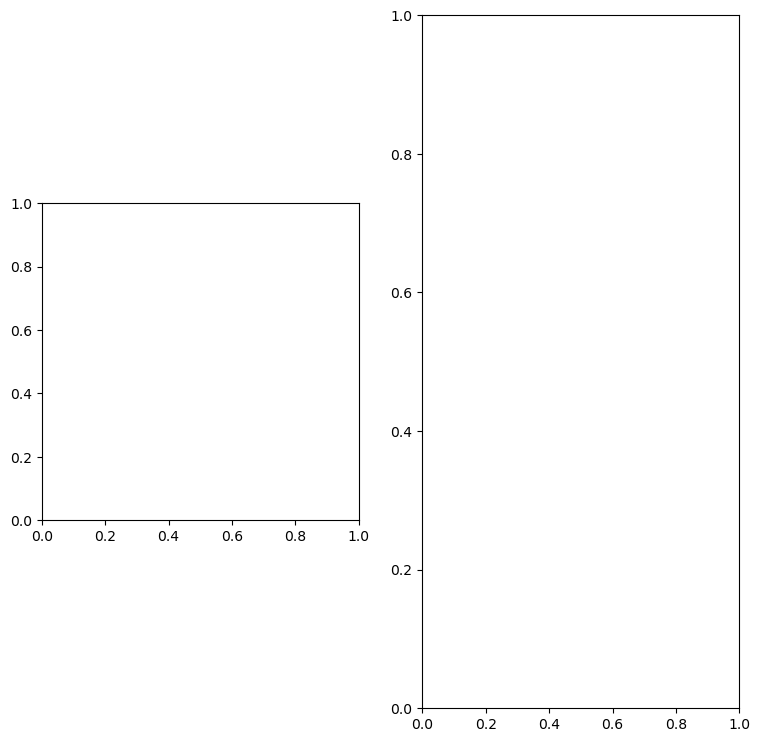

In [39]:
#7.7

from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy as np

hdulist = fits.open('ngc6946.fits')
# hdulist.info()
datIN = hdulist[0].data
hdulist.close()


def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen,_= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

X0 = Y0 = 50
alpha = np.radians(30)

datOUT = np.zeros_like(datIN)*np.nan
for i in range(datOUT.shape[0]):
    for j in range(datOUT.shape[1]):
        # We need to rotate clockwise to find this position
        # in the unrotated image!
        Xip =  np.cos(alpha)*(j-X0) + np.sin(alpha)*(i-Y0)
        Yip = -np.sin(alpha)*(j-X0) + np.cos(alpha)*(i-Y0)
        Xip += X0 ; Yip += Y0
        datOUT[i,j] = bilinearIP(datIN, Xip, Yip)

fig = figure(figsize=(9,9))
frame1 = fig.add_subplot(1,2,1)
frame2 = fig.add_subplot(1,2,2)
im1 = frame1.imshow(datIN, interpolation='none', origin="lower", cmap='jet')
im2 = frame2.imshow(datOUT, interpolation='none', origin="lower", cmap='jet')

show()

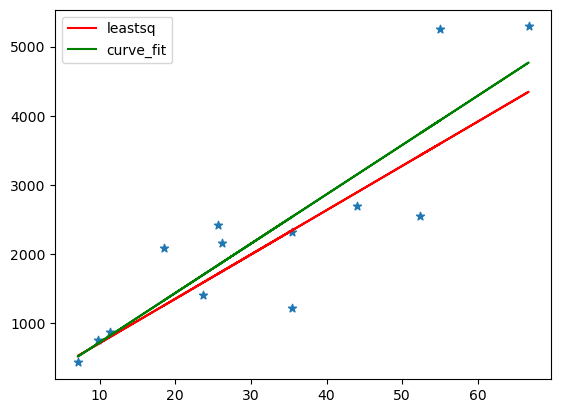

In [19]:
#7.10
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq, curve_fit

fig, ax = plt.subplots()

data = np.array([
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
])
data = np.reshape(data, (13, 4))

x = data[:, 0]
y = data[:, 1]
dx = data[:, 2]
dy = data[:, 3]

# y = m * x + b
def residuals(params, x, y, dy):
    m, b = params
    return (y - (m*x + b))/dy

init_guess = [67, 0]
result = leastsq(residuals, init_guess, args=(x, y, dy))
fit = result[0]

def func(x, m, b):
    return m*x + b
res, _ = curve_fit(func, x, y)

ax.scatter(x, y, marker='*')
ax.plot(x, fit[0]*x + fit[1], color='r', label='leastsq')
ax.plot(x, res[0]*x + res[1], color='g', label='curve_fit')
plt.legend()

In [ ]:
#7.14

